# Main results

## 1. Build model

In [14]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
# Filter out distutils warning in pd.datareader
import warnings

warnings.filterwarnings(
    "ignore",
    message="distutils Version classes are deprecated.*",
    category=DeprecationWarning,
)

In [16]:
from src import (
    download_save_raw_data,
    clean_save_data,
    create_save_portfolios,
    build_save_model,
)


from configs import PROJ_CONFIG

### 1.a. Download data (Resource intensive)

In [11]:
download_save_raw_data(PROJ_CONFIG)

2026-04-11 14:08:12 | +  96.442s | INFO | Starting to download all necessary data for the project...
--------------------------------------------------------------------------------


Loading library list...


2026-04-11 14:08:16 | +   4.138s | INFO | Successfully connected to WRDS database


Done


2026-04-11 14:08:23 | +   6.980s | DEBUG | Downloaded monthly prices for the observable universe of stocks from WRDS from 2009-05-01 to 2009-12-31
2026-04-11 14:08:32 | +   9.525s | DEBUG | Downloaded monthly prices for the observable universe of stocks from WRDS from 2010-01-01 to 2010-12-31
2026-04-11 14:08:43 | +  11.099s | DEBUG | Downloaded monthly prices for the observable universe of stocks from WRDS from 2011-01-01 to 2011-12-31
2026-04-11 14:08:55 | +  11.819s | DEBUG | Downloaded monthly prices for the observable universe of stocks from WRDS from 2012-01-01 to 2012-12-31
2026-04-11 14:09:08 | +  13.325s | DEBUG | Downloaded monthly prices for the observable universe of stocks from WRDS from 2013-01-01 to 2013-12-31
2026-04-11 14:09:23 | +  14.497s | DEBUG | Downloaded monthly prices for the observable universe of stocks from WRDS from 2014-01-01 to 2014-12-31
2026-04-11 14:09:37 | +  14.149s | DEBUG | Downloaded monthly prices for the observable universe of stocks from WRDS f

### 1.b. Process data (Resource intensive)

In [35]:
clean_save_data(PROJ_CONFIG)

2026-05-13 13:11:55 | +   0.000s | INFO | Starting importing raw data....
--------------------------------------------------------------------------------
2026-05-13 13:11:56 | +   0.881s | INFO | Successfully downloaded all raw data
2026-05-13 13:11:56 | +   0.001s | INFO | Starting data cleaning process....
--------------------------------------------------------------------------------
2026-05-13 13:11:56 | +   0.002s | INFO | Cleaned the factor data
2026-05-13 13:11:56 | +   0.005s | DEBUG | Monthly factor data sample:

            Mkt-RF     SMB     HML     RMW     CMA      RF
date                                                      
2009-06-01  0.0042  0.0227 -0.0276 -0.0141 -0.0037  0.0001
2009-07-01  0.0774  0.0231  0.0489 -0.0026  0.0308  0.0001
2009-08-01  0.0333 -0.0010  0.0760 -0.0285  0.0330  0.0001
2009-09-01  0.0408  0.0272  0.0115  0.0115  0.0034  0.0001
2009-10-01 -0.0255 -0.0485 -0.0417  0.0422 -0.0148  0.0000

2026-05-13 13:11:56 | +   0.030s | INFO | Finished clean

### 1.c. Create the portfolios

In [36]:
create_save_portfolios(PROJ_CONFIG)

2026-05-13 13:12:01 | +   0.078s | INFO | Starting to download processed data...
--------------------------------------------------------------------------------
2026-05-13 13:12:02 | +   0.691s | INFO | Successfully downloaded the processed data
2026-05-13 13:12:02 | +   0.001s | INFO | Starting to create portfolios....
--------------------------------------------------------------------------------
2026-05-13 13:12:02 | +   0.298s | INFO | Successfully assigned industries to firms according to the Fama-French industry portfolios
2026-05-13 13:12:12 | +  10.467s | INFO | Dropped non-significant portfolios with less than 10 firms.            
Number of portfolios dropped: 7 (48->41)
2026-05-13 13:12:12 | +   0.006s | INFO | Dropped portfolios with less than 26 occurances over entire period.
2026-05-13 13:12:12 | +   0.014s | INFO | Dropped portfolios with less than 26 occurances for each subperiod period.
2026-05-13 13:12:12 | +   0.001s | INFO | Dropped all non-significant portfolios.

### 1.d. Create the model and run the regression

In [27]:
build_save_model(PROJ_CONFIG)

2026-05-14 13:36:03 | + 141.459s | INFO | Starting to download portfolio data...
--------------------------------------------------------------------------------
2026-05-14 13:36:03 | +   0.215s | INFO | Downloaded portfolio data successfully
2026-05-14 13:36:03 | +   0.002s | INFO | Starting analysis of the entire period...
--------------------------------------------------------------------------------
2026-05-14 13:36:03 | +   0.089s | INFO | Extracted factor loadings successfully for multiple stocks
2026-05-14 13:36:04 | +   0.413s | INFO | Predicted returns successfully using the factor model
2026-05-14 13:36:04 | +   0.010s | INFO | Compared predicted and actual returns successfully
2026-05-14 13:36:04 | +   0.003s | INFO | Tested the significance of model parameters successfully
2026-05-14 13:36:04 | +   0.001s | INFO | Successfully analysed portfolios for the entire period
2026-05-14 13:36:04 | +   0.001s | INFO | Starting Analysis for subperiods...
----------------------------

# 2. Data Analysis

## Imports

In [11]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
from typing import List, Dict, Tuple, Any

# Set matlplotlib to inline mode
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [13]:
# Import the data
from configs import PLOTTING_CONFIG, ANALYSIS_PATHS, PROJ_CONFIG
from src.plotting import PLOTTER
from src.utils import import_analysis_data

plotter: PLOTTER = PLOTTER(PLOTTING_CONFIG)

# Import files and set index
monthly_factor_loadings, monthly_predicted_returns, factor_loadings_overtime = (
    import_analysis_data()
)

## Analysis of the changes in Beta

In [14]:
# Filter out only the betas
betas_over_time: pd.DataFrame = factor_loadings_overtime.loc["Beta"].swaplevel(axis=1)
errors_over_time: pd.DataFrame = factor_loadings_overtime.loc["StdError"].swaplevel(
    axis=1
)

# Get the different timeframes
timeframes: pd.Index = betas_over_time.columns.levels[0]
portfolios: pd.Index = betas_over_time.columns.levels[1]

In [15]:
# Get the changes in betas compared to the previous period
ORDERED_TIMEFRAME: List[str] = [
    "07/2009:01/2015",
    "01/2015:02/2020",
    "02/2020:12/2023",
    "12/2023:01/2026",
]

In [16]:
# Get the changes in betas compared to the entire period
changes_betas_entire_period = pd.DataFrame()
for timeframe in timeframes:
    if timeframe != "Entire Period":
        diff = (
            betas_over_time.loc[:, timeframe] - betas_over_time.loc[:, "Entire Period"]
        )
        diff.columns = pd.MultiIndex.from_product([[timeframe], diff.columns])
        changes_betas_entire_period = pd.concat(
            [changes_betas_entire_period, diff], axis=1
        )

In [17]:
# Get changes in betas from period to period
changes_betas_period_wise = pd.DataFrame()
t_stat_beta_similarity_period_wise = pd.DataFrame()

for i in range(1, len(ORDERED_TIMEFRAME)):
    current_timeframe: str = ORDERED_TIMEFRAME[i]
    previous_timeframe: str = ORDERED_TIMEFRAME[i - 1]
    transition: str = f"{previous_timeframe} -> {current_timeframe}"

    # Data
    prev_beta: pd.DataFrame = betas_over_time.loc[:, previous_timeframe]
    curr_beta: pd.DataFrame = betas_over_time.loc[:, current_timeframe]

    prev_stderr: pd.DataFrame = errors_over_time.loc[:, previous_timeframe]
    curr_stderr: pd.DataFrame = errors_over_time.loc[:, current_timeframe]

    # Difference in betas
    diff: pd.DataFrame = curr_beta - prev_beta

    # t-statistic for the difference in betas
    t_stats: pd.DataFrame = abs(diff / np.sqrt(prev_stderr**2 + curr_stderr**2))

    # Add transition as outer column level and add info to the dataframes
    diff.columns = pd.MultiIndex.from_product([[transition], diff.columns])
    t_stats.columns = pd.MultiIndex.from_product([[transition], t_stats.columns])

    changes_betas_period_wise = pd.concat([changes_betas_period_wise, diff], axis=1)
    t_stat_beta_similarity_period_wise = pd.concat(
        [t_stat_beta_similarity_period_wise, t_stats], axis=1
    )

In [18]:
# Check if the changes in betas are significant based on the t-statistic and the significance level
significant_changes_period_wise: pd.Series = (
    t_stat_beta_similarity_period_wise > PROJ_CONFIG.T_TEST_SIGNIFICANCE_LEVEL
)

# Count the number of significant changes in betas for each transition
number_beta_changes_period_wise: pd.Series = (
    (t_stat_beta_similarity_period_wise > PROJ_CONFIG.T_TEST_SIGNIFICANCE_LEVEL)
    .T.groupby(level=0)
    .sum()
)

print(number_beta_changes_period_wise)

Factor                              Alpha  CMA  HML  Mkt-RF  RMW  SMB
01/2015:02/2020 -> 02/2020:12/2023      2    7    9       7    4    3
02/2020:12/2023 -> 12/2023:01/2026      2    5   12       1    5    4
07/2009:01/2015 -> 01/2015:02/2020      4    6    4       3    1    3


In [19]:
# Desciptors
DESCRIPTORS: Tuple[str] = (
    "Mean Absolute Change",
    "Mean Change",
    "Max Change",
    "Min Change",
)
BETAS: List[str] = ["CMA", "HML", "Mkt-RF", "RMW", "SMB"]


# Function to retrieve the start date for ordering purposes
def get_start_date(col):
    start = col.split(":")[0]
    return pd.to_datetime(start, format="%m/%Y")


def sort_cols_level1(col) -> Tuple[Any, Any]:
    if col in DESCRIPTORS:
        return (0, col)
    else:
        return (1, col)


def get_description_stats(df: pd.DataFrame) -> pd.DataFrame:
    # Calculate the mean absolute change for each portfolio and timeframe
    df.loc["Mean beta changes", :] = df.loc[BETAS].abs().mean()

    df.loc["Mean squared beta changes", :] = df.loc[BETAS].pow(2).mean()

    # Calculate the mean squared change in each timeperiod for comparability
    for timeframe in df.columns.levels[0]:
        df[timeframe, "Mean Absolute Change"] = df[timeframe].abs().mean(axis=1)
        df[timeframe, "Mean Change"] = df[timeframe].mean(axis=1)
        df[timeframe, "Max Change"] = df[timeframe].max(axis=1)
        df[timeframe, "Min Change"] = df[timeframe].min(axis=1)

        # Mark the Mean Absolute Change and "Mean squared beta changes" intersection as undefined
        df.loc["Mean squared beta changes", (timeframe, "Mean Absolute Change")] = pd.NA

    # Sort the columns first by the timeframe and then by the descriptor
    df.sort_index(
        axis=1, level=1, inplace=True, key=lambda cols: cols.map(sort_cols_level1)
    )
    df.sort_index(
        axis=1,
        level=0,
        inplace=True,
        key=lambda cols: cols.map(get_start_date),
        sort_remaining=False,
    )
    return df


changes_betas_entire_period = get_description_stats(changes_betas_entire_period)
changes_betas_period_wise = get_description_stats(changes_betas_period_wise)

In [20]:
def split_data_for_analysis(
    df: pd.DataFrame,
) -> Dict[str, pd.DataFrame]:
    # Create the dictionary to hold the data
    data_dict = {"entire data": df}

    # Descriptions
    data_dict["descriptions"] = df.loc[
        :, df.columns.get_level_values(1).isin(DESCRIPTORS)
    ]

    # Main Portfolios
    data_dict["main_portfolios"] = df.loc[
        :,
        ~df.columns.get_level_values(1).str.contains("-")
        & ~df.columns.get_level_values(1).isin(DESCRIPTORS),
    ]

    if PROJ_CONFIG.CREATE_MARKETCAP_PORTFOLIOS:
        # Sub portfolios
        data_dict["subportfolios"] = df.loc[
            :,
            df.columns.get_level_values(1).str.contains("-")
            & ~df.columns.get_level_values(1).isin(DESCRIPTORS),
        ]

    else:
        data_dict["subportfolios"] = pd.DataFrame(columns=["EMPTY"])

    return data_dict


data_period_wise: Dict[str, pd.DataFrame] = split_data_for_analysis(
    changes_betas_period_wise
)
data_compared_to_entire_period: Dict[str, pd.DataFrame] = split_data_for_analysis(
    changes_betas_entire_period
)

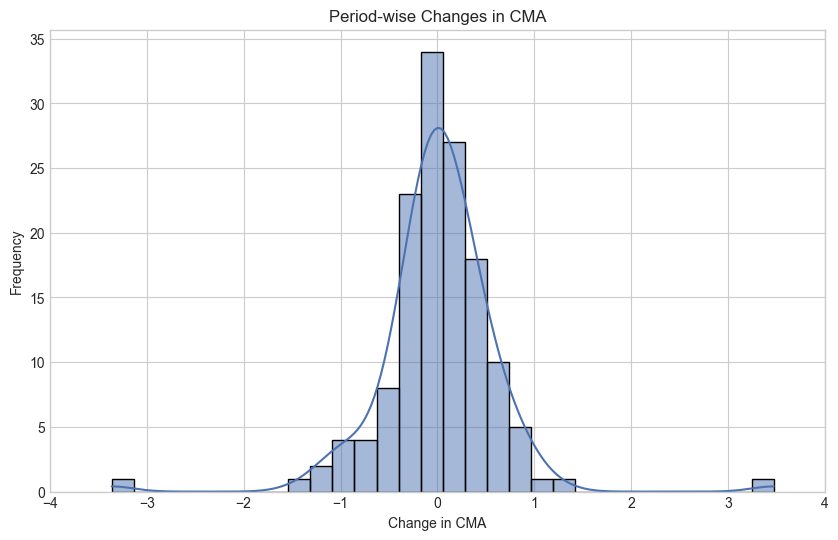

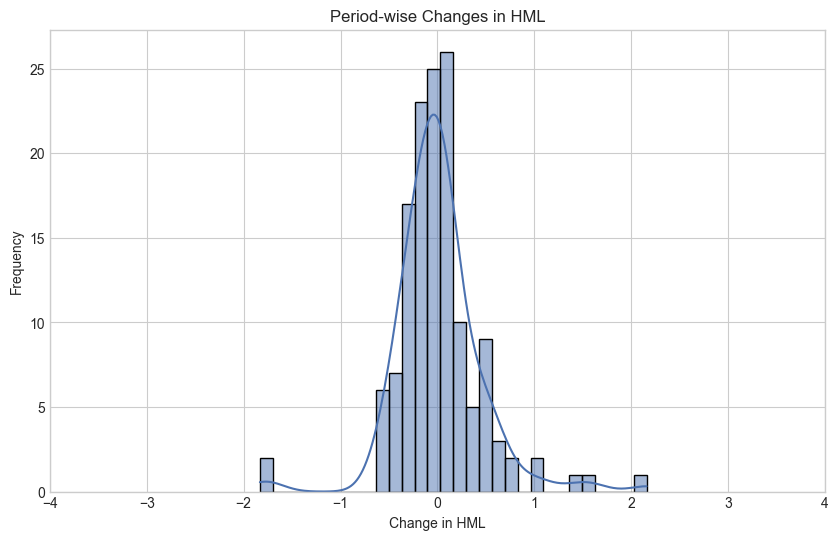

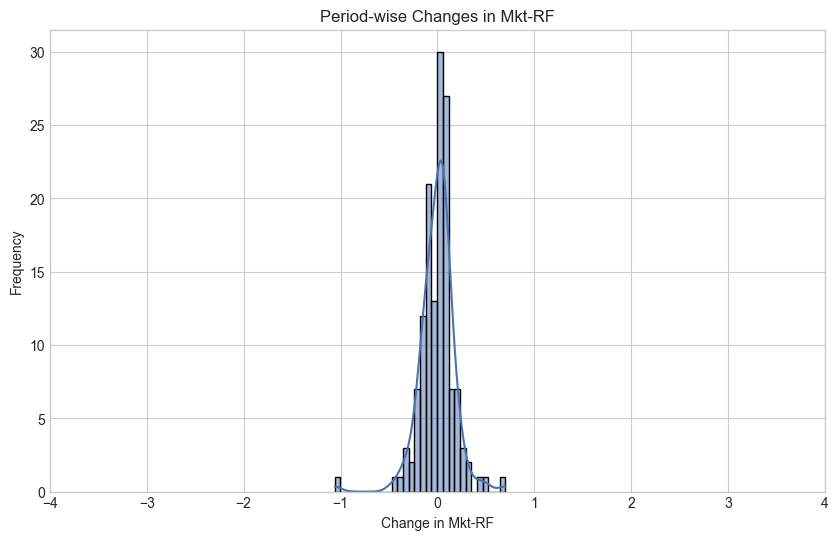

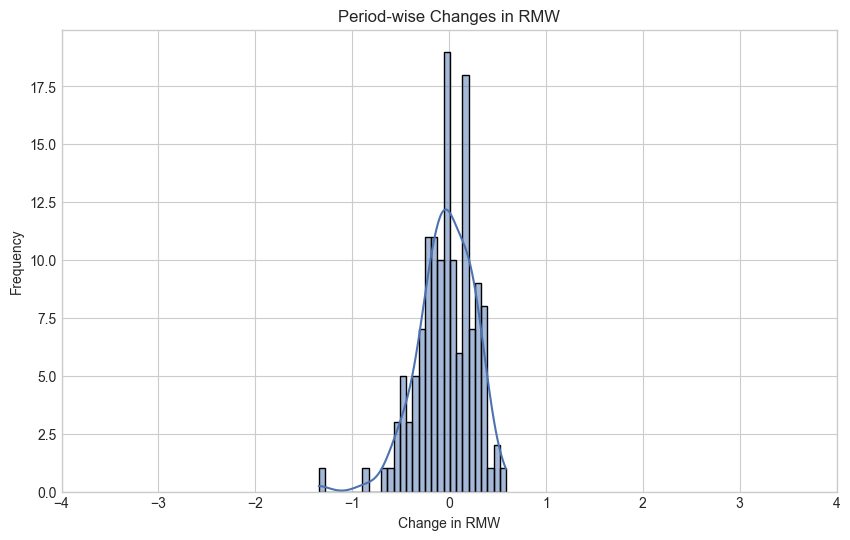

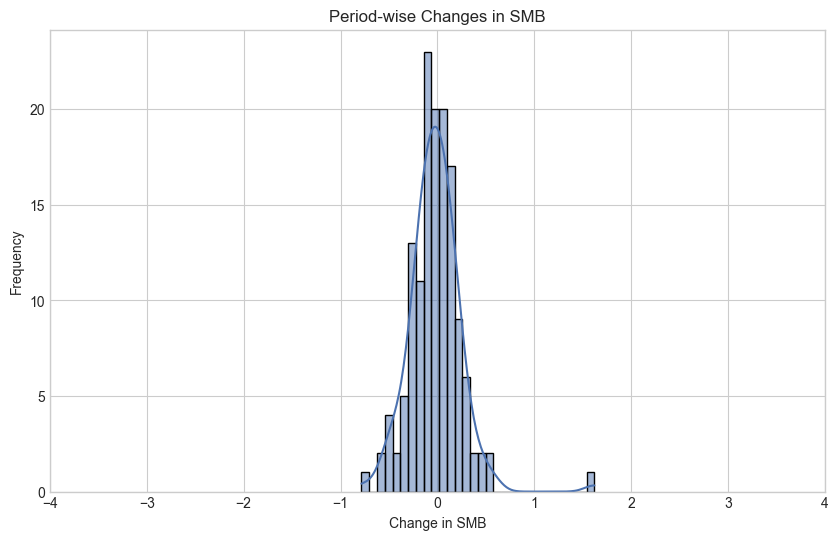

In [21]:
beta_info_entire_period: pd.DataFrame = changes_betas_entire_period.loc[
    BETAS, ~changes_betas_entire_period.columns.get_level_values(1).isin(DESCRIPTORS)
].copy()

# Get the max and min beta changes to align all on the same axis and round to the max integer
max_beta_change: float = round(beta_info_entire_period.values.max() + 0.5, 0)
min_beta_change: float = round(beta_info_entire_period.values.min() - 0.5, 0)

# Plot the betas
for beta in BETAS:
    plotter.plot_histogram_changes_over_time(
        df=beta_info_entire_period,
        beta=beta,
        x_start=min_beta_change,
        x_end=max_beta_change,
        save=True,
    )

In [ ]:
# Save the data
for name, df in data_period_wise.items():
    df.to_csv(
        ANALYSIS_PATHS.RESULT_TABLES_DIR / f"changes_betas_period_wise_{name}.csv",
    )

for name, df in data_compared_to_entire_period.items():
    df.to_csv(
        ANALYSIS_PATHS.RESULT_TABLES_DIR
        / f"changes_betas_compared_to_entire_period_{name}.csv"
    )

number_beta_changes_period_wise.to_csv(
    ANALYSIS_PATHS.RESULT_TABLES_DIR / "count_significant_beta_changes_per_period.csv",
)

                          07/2009:01/2015                                   \
Ticker                         Max Change Mean Absolute Change Mean Change   
Factor                                                                       
Alpha                            0.010238             0.004201    0.000266   
CMA                              0.919728             0.472434   -0.134788   
HML                              0.770274             0.230939   -0.014412   
Mkt-RF                           0.702674             0.106973    0.049985   
RMW                              0.517353             0.246877   -0.053440   
SMB                              0.448775             0.162661   -0.034280   
Mean beta changes                1.058176             0.243977    0.243977   
Mean squared beta changes        2.488505                  NaN    0.166200   

                                                                         \
Ticker                    Min Change  Aircraft Almost Nothing   Ap